In [5]:
%pip install pandas scikit-learn tensorflow seaborn
import pandas as pd

  Using cached pandas-3.0.0-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached tensorflow-2.20.0-cp313-cp313-win_amd64.whl.metadata (4.6 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached numpy-2.4.2-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached scipy-1.17.0-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-1


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
df=pd.read_csv('dataset/respiratory symptoms and treatment.csv')

NameError: name 'pd' is not defined

In [34]:
df['Symptoms'].value_counts()

Symptoms
shortness of breath                1517
Wheezing                           1360
chest pain                         1200
mucus                              1152
yellow cough                       1118
Fatigue                            1008
chronic cough                       864
cold                                845
Low-grade fever                     685
Nausea                              672
Feeling run-down or tired           624
whistling sound while breathing     538
Runny nose                          535
stuffy nose                         489
Chest congestion                    440
wheezing                            434
greenish cough                      336
cough with blood                    336
Fever                               336
sweating                            336
shaking                             336
Rapid breathing                     336
shallow breathing                   336
 low energy                         336
Loss of appetite               

In [35]:
df['Symptoms'].unique()

<StringArray>
[                     ' coughing ',      'tight feeling in the chest',
                       ' wheezing',            ' shortness of breath',
             'shortness of breath',                       ' coughing',
                        'coughing',                           'fever',
                            'cold',                        'wheezing',
                         'allergy',                      'Runny nose',
                     'stuffy nose',                 'Low-grade fever',
                'Chest congestion',                        'Wheezing',
 'whistling sound while breathing',                    'yellow cough',
       'Feeling run-down or tired',                           'mucus',
                      'chest pain',                   'chronic cough',
                         'Fatigue',                               nan,
                  'greenish cough',                'cough with blood',
                           'Fever',                        'swe

In [37]:
df['Symptoms']=df['Symptoms'].str.strip()

In [38]:
len(df['Symptoms'].value_counts())

31

In [15]:
len(df['Symptoms'].value_counts())

31

In [18]:
import seaborn as sns

<Axes: xlabel='Symptoms', ylabel='Count'>

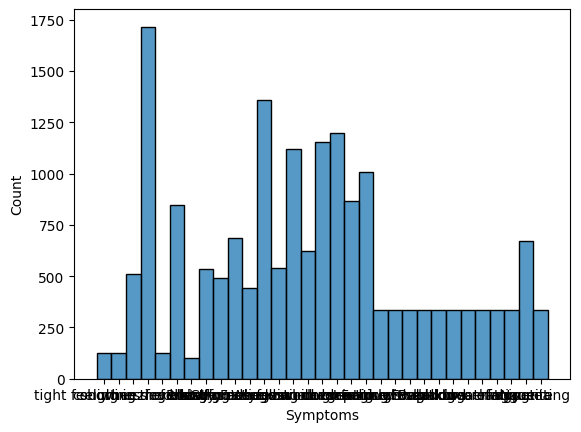

In [19]:
sns.histplot(df['Symptoms'])

In [39]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras import layers, models

In [40]:
# 1. Load and Basic Cleaning
df = df.drop(columns=['Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8','Treatment','Nature']) # Drop empty columns
df['Disease'] = df['Disease'].str.lower().str.strip()

In [41]:
# 2. Fill Missing Values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Sex'] = df['Sex'].fillna('unknown')
df['Symptoms'] = df['Symptoms'].fillna('unknown')


In [42]:
df_features = pd.get_dummies(df[['Age', 'Sex', 'Symptoms']], drop_first=True)


In [43]:
# Label encode target
le = LabelEncoder()
y = le.fit_transform(df['Disease'])
num_classes = len(le.classes_)

In [45]:
df_features.head()

,Age,Sex_male,Sex_not to say,Sex_unknown,Symptoms_Fatigue,Symptoms_Feeling run-down or tired,Symptoms_Fever,Symptoms_Loss of appetite,Symptoms_Low-grade fever,Symptoms_Nausea,...,Symptoms_shallow breathing,Symptoms_shortness of breath,Symptoms_stuffy nose,Symptoms_sweating,Symptoms_tight feeling in the chest,Symptoms_unknown,Symptoms_vomiting,Symptoms_wheezing,Symptoms_whistling sound while breathing,Symptoms_yellow cough
0,5.0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,4.0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
2,6.0,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,7.0,True,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
4,9.0,True,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False


In [46]:
# 4. Split and Scale
X_train, X_test, y_train, y_test = train_test_split(df_features, y, test_size=0.2, random_state=42)

In [47]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [48]:
# 5. Build the ANN
model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.2), # Prevents overfitting
    layers.Dense(32, activation='relu'),
    layers.Dense(num_classes, activation='softmax') # Multi-class output
])

c:\Users\zulqa\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [49]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [50]:
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1)


Epoch 1/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7509 - loss: 0.6271 - val_accuracy: 0.8555 - val_loss: 0.3500
Epoch 2/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8425 - loss: 0.3695 - val_accuracy: 0.8651 - val_loss: 0.3222
Epoch 3/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8539 - loss: 0.3385 - val_accuracy: 0.8741 - val_loss: 0.3042
Epoch 4/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8563 - loss: 0.3248 - val_accuracy: 0.8762 - val_loss: 0.2933
Epoch 5/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8607 - loss: 0.3150 - val_accuracy: 0.8624 - val_loss: 0.2924
Epoch 6/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8632 - loss: 0.3083 - val_accuracy: 0.8651 - val_loss: 0.2861
Epoch 7/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8631 - loss: 0.3018 - val_accuracy: 0.8672 - val_loss: 0.2785
Epoch 8/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8664 - loss: 0.2965 - val_accuracy: 0.

In [51]:
# 7. Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.2f}")

113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8854 - loss: 0.2590
Test Accuracy: 0.89


In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Dropout
def build_model(hp):
    model = Sequential()
    counter = 0

    for i in range(hp.Int('num_layers',min_value=1,max_value=10)):
        if counter == 0:
            model.add(
                Dense(
                    hp.Int('units'+str(i), min_value=8, max_value=128)
                    , activation=hp.Choice('activation'+str(i) , values=['relu','tanh','sigmoid']),
                    input_dim=8))
            model.add(Dropout(hp.Choice('Dropout'+str(i),values=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9])))

        else:
            model.add(
                Dense(
                    hp.Int('units'+str(i), min_value=8, max_value=128)
                    , activation=hp.Choice('activation'+str(i) , values=['relu','tanh','sigmoid'])
                ))
            model.add(Dropout(hp.Choice('Dropout'+str(i),values=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9])))
        counter += 1
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer=hp.Choice('optimizer',values=['rmsprop','adam','sgd','nadam','adadelta'])
                  ,loss='binary_crossentropy', metrics=['accuracy'])
    return model
